In [21]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator
load_dotenv()

True

In [22]:
# model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
model = ChatMistralAI(model="mistral-small-latest")

In [23]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback for the essay")
    score: int = Field(description="Score out of 10",ge=0,le=10)

In [24]:
structured_model = model.with_structured_output(EvaluationSchema)

In [25]:
essay = """
## Essay Title Options:

*   **The AI Awakening: India's Leap into the Future of Artificial Intelligence**
*   **From Code to Consciousness: Charting the Rise of AI in India**
*   **India's AI Revolution: Opportunities, Challenges, and the Road Ahead**
*   **Shaping Tomorrow: How AI is Redefining India's Economic and Social Landscape**
*   **The Smart Nation: Unpacking India's Burgeoning AI Ecosystem**

---

## Essay Outline: The Rise of AI in India

**Target Audience:** General readers, business professionals, technology enthusiasts, students, policymakers interested in India's digital transformation.

---

### I. Introduction (approx. 150-200 words)

*   **A. Hook:** Start with a captivating statement about the global AI phenomenon and its transformative power.
    *   *Example:* "From self-driving cars to personalized recommendations, Artificial Intelligence (AI) is no longer a futuristic dream but a tangible force reshaping our world. And at the heart of this global AI revolution, a new powerhouse is emerging: India."
*   **B. Context Setting: India's Unique Position:**
    *   Highlight India's large, tech-savvy population, robust IT services industry, and rapid digitalization (e.g., UPI, Aadhaar).
    *   Mention the blend of traditional challenges and modern solutions that make India a fertile ground for AI innovation.
*   **C. Thesis Statement:** State the blog's main argument – that AI is not just a technological adoption for India, but a strategic imperative and a catalyst for unprecedented growth and problem-solving across various sectors, despite inherent challenges.
*   **D. What Readers Will Learn:** Briefly outline the key areas the blog will cover (e.g., catalysts, sectoral impact, key players, challenges, future outlook).

### II. The Catalysts: Why is AI Surging in India Now? (approx. 250-300 words)

*   **A. Digital Infrastructure Boom:**
    *   **Jio Revolution & Affordable Data:** Widespread internet access, especially in rural areas, creating a massive user base and data pool.
    *   **UPI & Digital Payments:** India's pioneering digital payment infrastructure generating vast amounts of transactional data for AI analysis.
    *   **Aadhaar & Digital Identity:** Enabling large-scale digital services and identity verification, crucial for AI applications.
*   **B. Government Initiatives & Vision:**
    *   **"AI for All" Vision:** NITI Aayog's national strategy focusing on inclusive AI development.
    *   **National AI Portal (indiaai.gov.in):** A hub for AI-related news, resources, and initiatives.
    *   **Digital India & Make in India:** Providing a broader framework for technological advancement and indigenous innovation.
    *   **Investment in Research & Development:** Setting up AI centers of excellence.
*   **C. A Deep Talent Pool:**
    *   **STEM Graduates:** India's large number of engineering and science graduates, a ready workforce for AI.
    *   **IT Services Backbone:** Existing expertise in software development and data management, easily transferable to AI.
    *   **Growing AI/ML Skill Development:** Rise of specialized courses, bootcamps, and certifications.
*   **D. Vibrant Startup Ecosystem & Funding:**
    *   Increasing venture capital interest in AI startups.
    *   Emergence of AI-first companies addressing specific Indian problems.

### III. AI in Action: Sectoral Impact & Transformative Use Cases (approx. 400-500 words)

*   **A. Healthcare:**
    *   **Diagnostics:** AI-powered tools for early detection of diseases (e.g., retinopathy, cancer screening).
    *   **Drug Discovery:** Accelerating research and development of new medicines.
    *   **Personalized Medicine:** Tailoring treatments based on individual genetic data.
    *   **Telemedicine & Remote Monitoring:** Increasing accessibility of healthcare in remote areas.
    *   *Example:* AI for TB detection, AI chatbots for patient queries.
*   **B. Agriculture:**
    *   **Crop Yield Optimization:** Predictive analytics for weather, soil conditions, pest detection.
    *   **Precision Farming:** Drone-based monitoring, automated irrigation.
    *   **Supply Chain Efficiency:** Reducing post-harvest losses.
    *   *Example:* Startups using AI to advise farmers on optimal planting/harvesting times.
*   **C. Finance (FinTech):**
    *   **Fraud Detection:** AI algorithms identifying suspicious transactions in real-time.
    *   **Personalized Banking:** Customized financial products and advice.
    *   **Credit Scoring:** Expanding access to credit for underserved populations using alternative data.
    *   **Customer Service:** AI chatbots for instant support.
    *   *Example:* UPI's fraud prevention, AI-driven lending platforms.
*   **D. Education:**
    *   **Personalized Learning:** Adaptive platforms tailoring content to individual student needs.
    *   **Smart Content Creation:** AI-generated learning materials.
    *   **Automated Grading & Feedback:** Streamlining administrative tasks.
    *   *Example:* Ed-tech platforms using AI to recommend courses or identify learning gaps.
*   **E. Customer Service & Retail:**
    *   **Chatbots & Virtual Assistants:** Enhancing customer experience across industries.
    *   **Personalized Recommendations:** AI-driven product suggestions in e-commerce.
    *   **Supply Chain Optimization:** Improving logistics and inventory management.
*   **F. Manufacturing & Smart Cities:**
    *   **Predictive Maintenance:** Reducing downtime in factories.
    *   **Traffic Management:** Optimizing traffic flow and reducing congestion.
    *   **Waste Management:** AI for efficient waste collection and segregation.

### IV. Key Players & Innovation Hubs (approx. 150-200 words)

*   **A. Indian Startups:** Highlight a few innovative Indian AI startups (e.g., in specific sectors like health-tech, agri-tech, fintech).
*   **B. Global Tech Giants:** Role of companies like Google, Microsoft, Amazon, IBM in setting up AI labs and investing in India.
*   **C. Academia & Research Institutions:** Contributions from IITs, IISc, and other universities in fundamental and applied AI research.
*   **D. Government-led Initiatives:** NITI Aayog, MeitY, and various ministries driving AI adoption.
*   **E. Major IT Service Companies:** TCS, Infosys, Wipro, HCLTech leveraging AI for client solutions globally.

### V. Challenges & Ethical Considerations (approx. 250-300 words)

*   **A. Job Displacement & Skilling Gap:**
    *   Fear of automation replacing human jobs.
    *   Need for massive reskilling and upskilling programs for the workforce.
    *   Importance of focusing on "AI augmentation" rather than pure replacement.
*   **B. Data Privacy & Security:**
    *   Concerns over sensitive personal data collection and usage.
    *   Importance of robust data protection laws (e.g., DPDP Act).
    *   Safeguarding against cyber threats targeting AI systems.
*   **C. Algorithmic Bias & Fairness:**
    *   Risk of AI systems perpetuating or amplifying existing societal biases due to biased training data.
    *   Need for diverse datasets and ethical AI development guidelines.
*   **D. Infrastructure Gaps:**
    *   Challenges in providing reliable internet connectivity and power to all regions.
    *   Need for powerful computing infrastructure (e.g., cloud, GPUs).
*   **E. Ethical AI Frameworks:**
    *   Developing clear guidelines for responsible AI development and deployment.
    *   Ensuring transparency, accountability, and human oversight in AI decisions.
*   **F. Accessibility & Digital Divide:**
    *   Ensuring AI benefits reach all segments of society, not just urban populations.
    *   Developing AI solutions in local languages.

### VI. The Road Ahead: India's AI Future (approx. 150-200 words)

*   **A. Vision for "AI for All":** Reiterate India's commitment to using AI for social good and inclusive growth.
*   **B. Focus on Indigenous Innovation:** Encouraging solutions tailored to India's unique challenges and opportunities.
*   **C. Global Leadership & Collaboration:** India's potential to become a global hub for ethical AI development and a partner in international AI governance.
*   **D. Policy Evolution:** Continuous adaptation of regulations to keep pace with technological advancements.
*   **E. Emphasis on Human-AI Collaboration:** The future isn't just AI, but how humans and AI work together.

### VII. Conclusion (approx. 100-150 words)

*   **A. Recap:** Briefly summarize India's rapid AI ascent, its immense potential, and the crucial challenges it faces.
*   **B. Reiterate Thesis:** Reinforce the idea that AI is a transformative journey for India, promising a smarter, more efficient, and potentially more equitable future.
*   **C. Call to Action/Final Thought:**
    *   Encourage readers to engage with AI, understand its implications, and participate in shaping its responsible development.
    *   End with an optimistic yet grounded outlook on India's role in the global AI landscape.
    *   *Example:* "The rise of AI in India is not just a technological story; it's a narrative of ambition, innovation, and a nation's determined stride towards a future where intelligence, both artificial and human, collaborates to solve some of the world's most pressing problems."

---

### VIII. SEO & Keywords:

*   **Primary Keywords:** AI in India, Artificial Intelligence India, India AI Revolution
*   **Secondary Keywords:** Indian AI startups, AI for social good India, AI impact on India, India digital transformation, AI challenges India, NITI Aayog AI, Indian tech talent, AI in healthcare India, AI in agriculture India, Fintech AI India.
*   **Long-tail Keywords:** How AI is changing India, Future of AI in India, Government initiatives for AI in India.

### IX. Potential Image Ideas:

*   Infographic showing AI growth trajectory in India.
*   Montage of AI applications across different sectors (hospital, farm, bank, classroom).
*   Image of a diverse group of Indian tech professionals collaborating.
*   Visual representation of data flowing into AI systems.
*   Map of India with AI innovation hubs highlighted.

---"""

In [26]:
prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10\n {essay}"
output = structured_model.invoke(prompt)

In [27]:
print(output.feedback)
print(output.score)

The essay outline is well-structured, comprehensive, and tailored to engage a diverse audience, including general readers, business professionals, technology enthusiasts, students, and policymakers. The outline effectively balances technical details with accessibility, ensuring that complex concepts like AI adoption, sectoral impact, and ethical considerations are presented in a digestible manner.

**Strengths:**
1. **Clarity and Organization:** The outline follows a logical progression, starting with an introduction that sets the context and ends with a conclusion that reinforces the thesis. Each section is clearly defined with sub-points that provide depth and specificity.
2. **Audience Awareness:** The outline demonstrates a strong understanding of the target audience. For instance, the inclusion of real-world examples (e.g., AI for TB detection, UPI's fraud prevention) makes the content relatable and engaging for both technical and non-technical readers.
3. **Comprehensiveness:** T

In [28]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int],operator.add] # operator is used to do [8] + [7] = [8,7]
    avg_score: float


In [29]:
def evaluate_language(state:UPSCState):
    prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10\n {state['essay']}"
    output = structured_model.invoke(prompt)
    return{
        'language_feedback' : output.feedback,
        'individual_scores' : [output.score]
    }

In [30]:
def evaluate_analysis(state:UPSCState):
    prompt = f"Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10\n {state['essay']}"
    output = structured_model.invoke(prompt)
    return{
        'analysis_feedback' : output.feedback,
        'individual_scores' : [output.score]
    }

In [31]:
def evaluate_thought(state:UPSCState):
    prompt = f"Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10\n {state['essay']}"
    output = structured_model.invoke(prompt)
    return{
        'clarity_feedback' : output.feedback,
        'individual_scores' : [output.score]
    }

In [32]:
def final_evaluation(state:UPSCState):
    # summary feedback
    prompt = f"Based on the following feedback create a summarized feedback \n language feedback - {state['language_feedback']} \n Depth of analysis feedback - {state['analysis_feedback']} \n Clarity Of thought - {state['clarity_feedback']}"
    overall_feedback = model.invoke(prompt).content

    #avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])
    return {'overall_feedback' : overall_feedback, 'avg_score': avg_score}


In [33]:
graph = StateGraph(UPSCState)
graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_analysis',evaluate_analysis)
graph.add_node('evaluate_thought',evaluate_thought)
graph.add_node('final_evaluation',final_evaluation)

In [34]:
graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START,'evaluate_thought')

graph.add_edge('evaluate_language','final_evaluation')
graph.add_edge('evaluate_analysis','final_evaluation')
graph.add_edge('evaluate_thought','final_evaluation')

graph.add_edge('final_evaluation',END)
workflow = graph.compile()

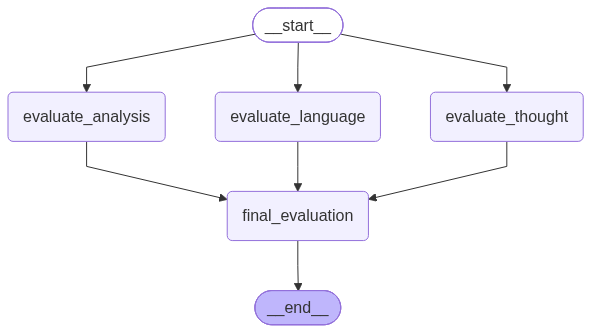

In [35]:
workflow

In [36]:
initial_state = {
    'essay' : essay
}
workflow.invoke(initial_state)

{'essay': '\n## Essay Title Options:\n\n*   **The AI Awakening: India\'s Leap into the Future of Artificial Intelligence**\n*   **From Code to Consciousness: Charting the Rise of AI in India**\n*   **India\'s AI Revolution: Opportunities, Challenges, and the Road Ahead**\n*   **Shaping Tomorrow: How AI is Redefining India\'s Economic and Social Landscape**\n*   **The Smart Nation: Unpacking India\'s Burgeoning AI Ecosystem**\n\n---\n\n## Essay Outline: The Rise of AI in India\n\n**Target Audience:** General readers, business professionals, technology enthusiasts, students, policymakers interested in India\'s digital transformation.\n\n---\n\n### I. Introduction (approx. 150-200 words)\n\n*   **A. Hook:** Start with a captivating statement about the global AI phenomenon and its transformative power.\n    *   *Example:* "From self-driving cars to personalized recommendations, Artificial Intelligence (AI) is no longer a futuristic dream but a tangible force reshaping our world. And at the